In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
meteo = pd.read_csv("meteo_togo_2024.csv")

# LINE PLOT 

In [3]:
meteo.shape

(72, 5)

In [4]:
display(meteo)

,ville,mois,mois_num,temperature_moy_c,precipitations_mm
0,Lomé,Janvier,1,21.2,11.2
1,Lomé,Février,2,24.7,0.0
2,Lomé,Mars,3,25.1,0.0
3,Lomé,Avril,4,27.4,156.5
4,Lomé,Mai,5,28.9,150.9
...,...,...,...,...,...
67,Dapaong,Août,8,30.4,77.8
68,Dapaong,Septembre,9,26.9,93.6
69,Dapaong,Octobre,10,24.8,103.8
70,Dapaong,Novembre,11,23.8,0.0


In [5]:
lome = meteo[meteo['ville'] == "Lomé"].sort_values('mois_num')

####  Un graphique en ligne de la température moyenne au fil des 12 mois, avec des marqueurs sur chaque point

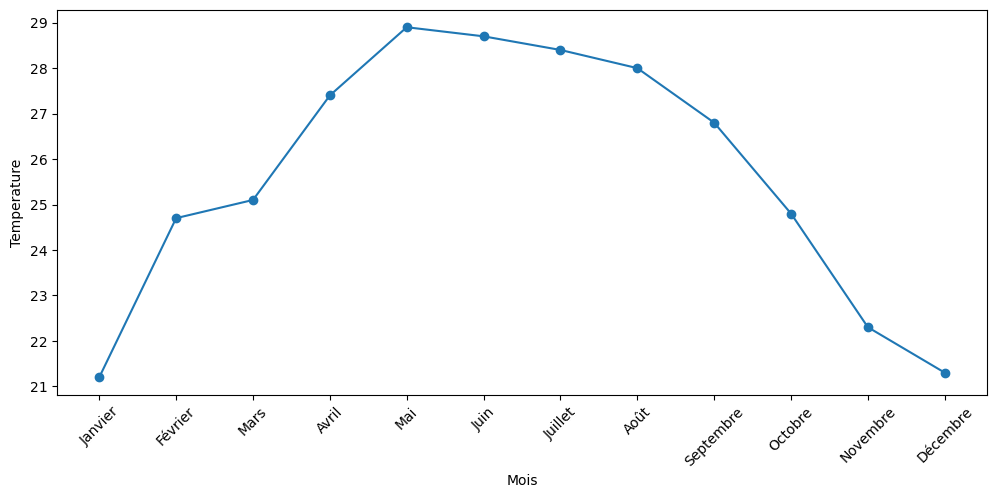

In [6]:
plt.figure(figsize=(12,5))

plt.plot(lome['mois'], lome['temperature_moy_c'], marker='o')
plt.xlabel("Mois")
plt.ylabel("Temperature")
plt.xticks(rotation=45) # Pivotement du label de x
plt.show()

#### Superposition avec la ville de Kara

In [7]:
kara = meteo[meteo['ville'] == "Kara"].sort_values('mois_num')

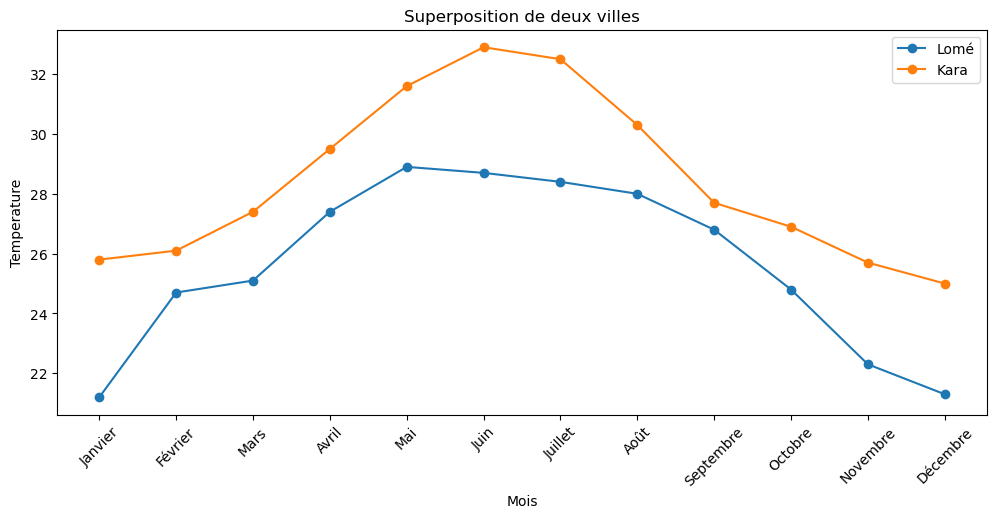

In [8]:
plt.figure(figsize=(12,5))

plt.plot(lome['mois'], lome['temperature_moy_c'], marker='o', label="Lomé")
plt.plot(kara['mois'], kara['temperature_moy_c'], marker='o', label="Kara")
plt.xlabel("Mois")
plt.ylabel("Temperature")
plt.xticks(rotation=45) # Pivotement du label de x
plt.legend()
plt.title("Superposition de deux villes")
plt.show()

# BAR PLOT

####  Calcule le total des précipitations sur l'année pour chaque ville 

In [9]:
precip_ville = meteo.groupby('ville')['precipitations_mm'].sum().sort_values(ascending=False)
precip_ville

ville
Lomé        1188.8
Atakpamé    1172.9
Kpalimé     1071.8
Sokodé       845.4
Kara         815.8
Dapaong      758.5
Name: precipitations_mm, dtype: float64

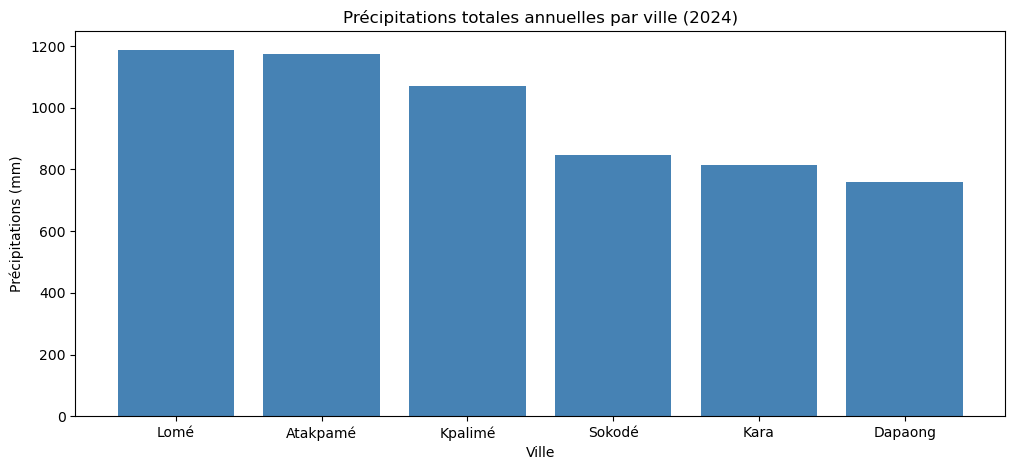

In [11]:
plt.figure(figsize=(12,5))

plt.bar(precip_ville.index, precip_ville.values, color="steelblue")
plt.title("Précipitations totales annuelles par ville (2024)")
plt.xlabel("Ville")
plt.ylabel("Précipitations (mm)")
plt.show()

#### Mettre en avant la ville la plus pluvieuse

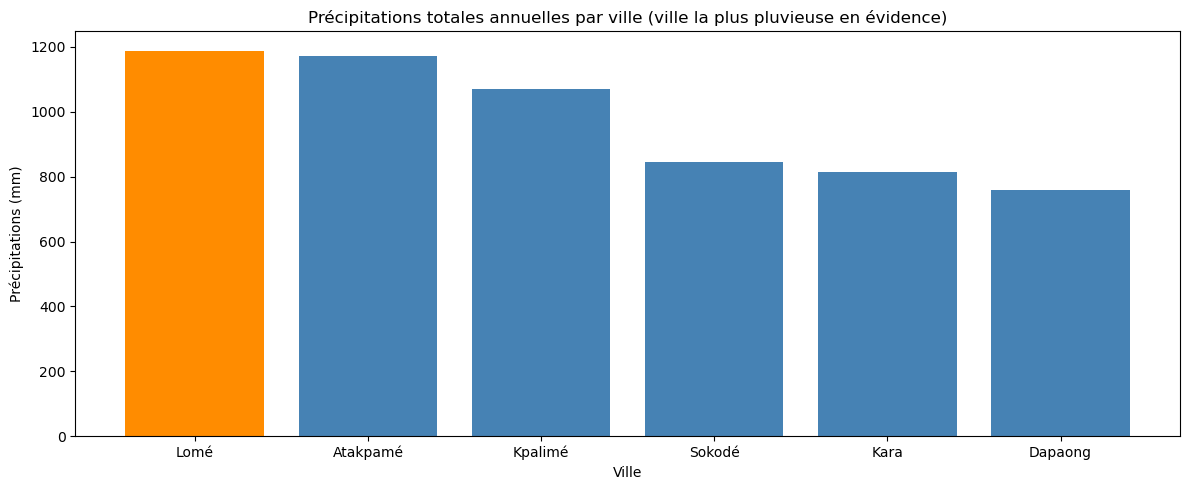

In [15]:
couleurs = ["darkorange" if v == precip_ville.index[0] else "steelblue"
            for v in precip_ville.index]
 
plt.figure(figsize=(12,5))

plt.bar(precip_ville.index, precip_ville.values, color=couleurs)
plt.title("Précipitations totales annuelles par ville (ville la plus pluvieuse en évidence)")
plt.xlabel("Ville")
plt.ylabel("Précipitations (mm)")
plt.tight_layout()
plt.show()

# PIE CHART (CAMEMBERT)

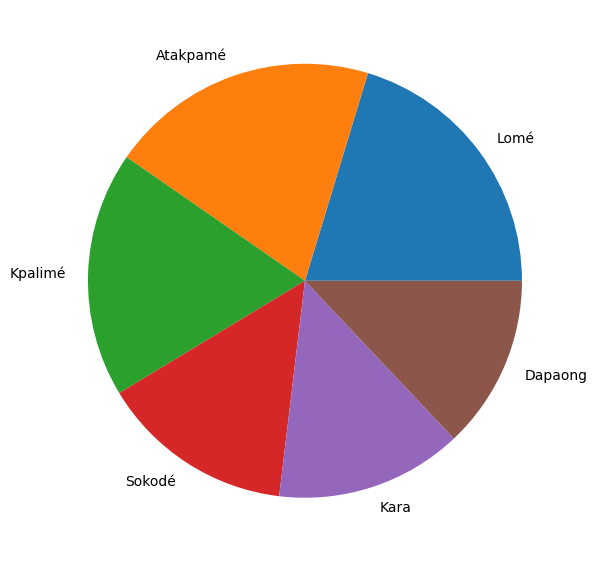

In [25]:
plt.figure(figsize=(7,10))

plt.pie(labels=precip_ville.index, x=precip_ville.values)
plt.show()

#### Afficher le pourcentage

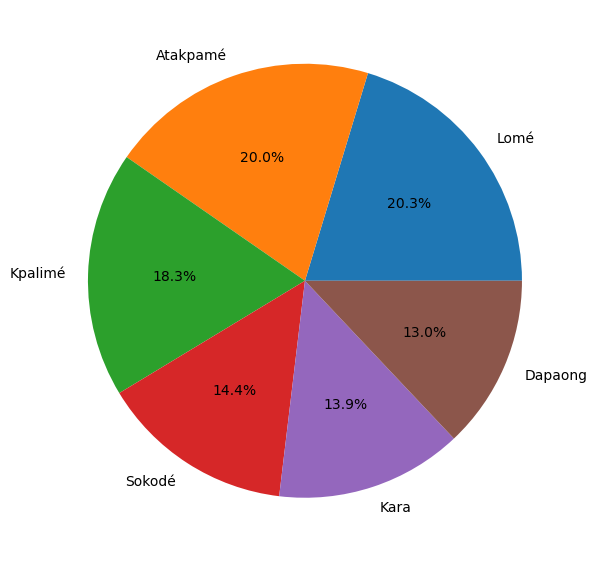

In [26]:
plt.figure(figsize=(7,10))

plt.pie(labels=precip_ville.index, x=precip_ville.values, autopct='%1.1f%%')
plt.title("otal des précipitations sur l'année pour chaque ville")
plt.show()